# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 2026-2027

**Major Project – Data Analytics**

---

### Introduction

The dataset represents agricultural activities carried out across different seasons, geographical areas and farming conditions. It contains information related to farming practices, environmental conditions, crop production, resource usage and economic performance.

This project aims to analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

### Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [ ]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.shape

(4000, 28)

The dataset contains 4,000 observations and 28 variables representing agricultural, environmental, resource, production and economic characteristics.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

there is no duplicate rows present

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [ ]:
df['Crop'].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

In [ ]:
df['State'].unique()

array(['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka',
       'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh'], dtype=object)

In [ ]:
df['Irrigation_Method'].unique()

array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

In [ ]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

In [ ]:
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

In [ ]:
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
Q1 = df.select_dtypes(include='number').quantile(0.25)
Q3 = df.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

outliers = ((df.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) |
            (df.select_dtypes(include='number') > (Q3 + 1.5 * IQR))).sum()

outliers.sort_values(ascending=False)

,0
Profit_INR,404
Production_Tonnes,333
Water_Efficiency_t_per_1000m3,322
Yield_Tonnes_Ha,302
Water_Used_m3,276
Revenue_INR,240
Potassium_kg_ha,32
Sunlight_Hours_Day,26
Phosphorus_kg_ha,16
Fertilizer_kg_ha,15


### Outlier Handling

Outliers were identified using the IQR (Interquartile Range) method.
Some numerical variables such as Profit, Production, Yield, Water Used, and Water Efficiency contained outlier observations.

The outliers were not removed because they may represent genuine differences between farms, such as variations in farm size, production, resource usage, and profitability. Removing these observations could affect the accuracy of the seasonal analysis.

Therefore, the original values were retained for further analysis.

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(4000, 28)

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Data Cleaning Summary

The dataset was checked and cleaned before performing the analysis. Missing values in Rainfall, Soil Moisture, and Yield were handled using median imputation. No duplicate records were found, and the data types of all variables were verified. Categorical values such as Season were checked for consistency. Outliers were identified using the IQR method and retained because they may represent genuine variations in agricultural conditions and farm performance.

After cleaning, the dataset was verified to ensure that it was ready for further analysis.

In [ ]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:
df['Season'].value_counts(normalize=True) * 100

,proportion
Season,
Kharif,44.475
Rabi,40.675
Zaid,14.850


### Seasonal Distribution

The dataset contains 4,000 agricultural records. Kharif has the highest number of records, followed by Rabi, while Zaid has the fewest records. Therefore, the number of observations is not equally distributed across the three seasons.

In [ ]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


### Average Yield by Season

The average yield was calculated for each agricultural season. The results show that the average yield varies across Kharif, Rabi, and Zaid seasons. This provides an initial measure for comparing seasonal agricultural performance.

In [ ]:
df.groupby('Season')['Production_Tonnes'].mean()

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


### Average Production by Season

The average production was calculated for Kharif, Rabi, and Zaid seasons. The results show differences in production across the seasons. Kharif has the highest average production, followed by Rabi and Zaid.

In [ ]:
df.groupby('Season')['Revenue_INR'].mean()

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


### Average Revenue by Season

The average revenue was calculated for each agricultural season. The results show that Kharif has the highest average revenue, followed by Rabi and Zaid. This indicates that seasonal conditions and agricultural performance may be associated with differences in revenue.

In [ ]:
df.groupby('Season')['Profit_INR'].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


### Average Profit by Season

The average profit was calculated for Kharif, Rabi, and Zaid seasons. Kharif has the highest average profit, while Rabi has a lower positive profit. Zaid shows a negative average profit, indicating that the average cost is higher than the average revenue for this season.

In [ ]:
df.groupby('Season')['Rainfall_mm'].mean()

,Rainfall_mm
Season,
Kharif,849.199663
Rabi,437.615366
Zaid,304.654714


### Average Rainfall by Season

The average rainfall was calculated for each agricultural season. Kharif receives the highest average rainfall, while Zaid receives the lowest. This shows that rainfall conditions vary considerably across the three seasons.

In [ ]:
season_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

season_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,
Kharif,6102.201237,5.891834,54.467903
Rabi,5846.987093,5.186122,40.482114
Zaid,6419.893939,4.413239,38.216667


### Water Usage, Water Efficiency and Disease/Pest Risk by Season

The average water usage, water efficiency, and disease/pest risk were calculated for each season. Zaid has the highest average water usage, while Kharif has the highest water efficiency. Kharif also shows the highest average disease/pest risk among the three seasons.

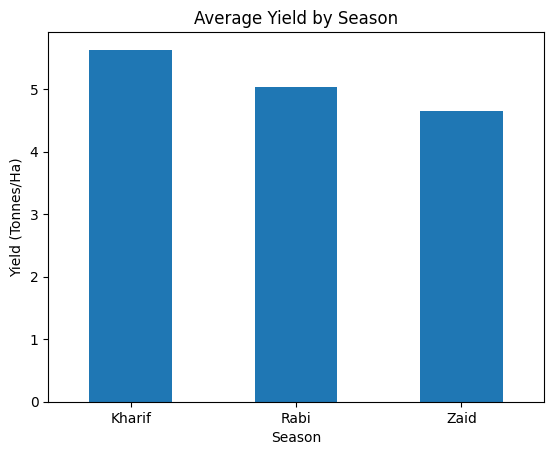

In [ ]:
import matplotlib.pyplot as plt

season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield.plot(kind='bar')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()

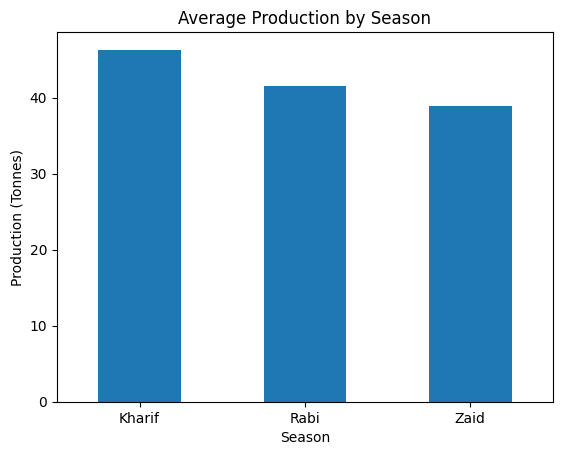

In [ ]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()

season_production.plot(kind='bar')
plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=0)
plt.show()

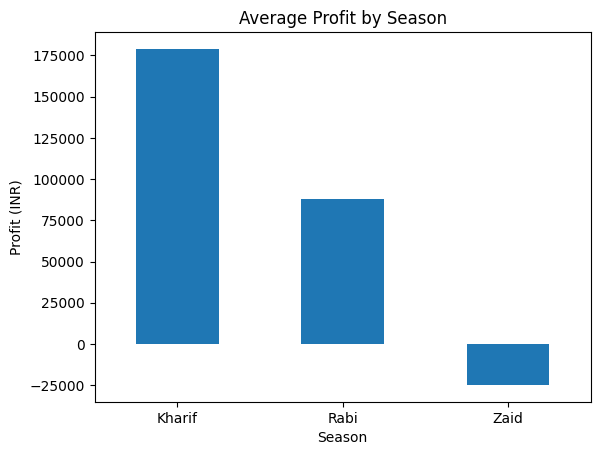

In [ ]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

season_profit.plot(kind='bar')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=0)
plt.show()

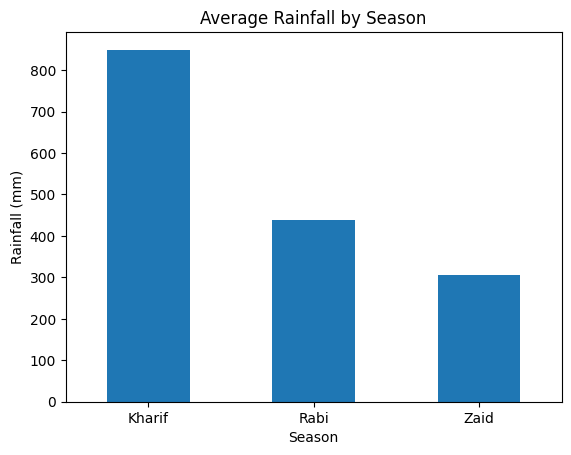

In [ ]:
season_rainfall = df.groupby('Season')['Rainfall_mm'].mean()

season_rainfall.plot(kind='bar')
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=0)
plt.show()

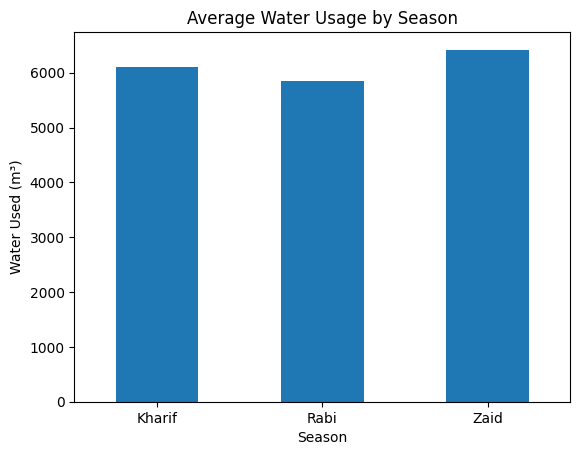

In [ ]:
season_water = df.groupby('Season')['Water_Used_m3'].mean()

season_water.plot(kind='bar')
plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Rainfall_mm': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Rainfall_mm,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,178914.65,849.20,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,87689.47,437.62,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,-24804.82,304.65,6419.89,4.41,38.22


### Key Findings from Seasonal Analysis

The seasonal analysis shows clear differences in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif has the highest average yield, production, revenue, and profit. Rabi shows moderate performance across the major indicators. Zaid has the lowest average yield and production and records a negative average profit.

Kharif receives the highest average rainfall and has the highest water efficiency. Zaid uses the highest amount of water on average but has the lowest water efficiency. Disease and pest risk is highest in Kharif and lowest in Zaid.

These findings show that seasonal conditions are associated with differences in agricultural productivity, profitability, and resource usage.

In [ ]:
crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

crop_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Chilli,1.54,12.38,1276777.23,750878.34
Cotton,1.23,9.40,639423.08,124546.92
Groundnut,1.32,9.66,542935.50,44858.12
Maize,2.71,21.78,457067.99,-83978.33
Pulses,0.92,7.40,528465.87,-4238.05
Rice,2.43,19.29,423615.26,-102213.50
Sugarcane,46.64,392.41,1371980.11,817187.99
Wheat,2.11,16.85,400104.89,-123398.34


### Crop-wise Performance Analysis

The crop-wise analysis compares the average yield, production, revenue, and profit of different crops. The results show substantial variation among crops. Sugarcane has the highest average yield and production in the dataset, while Chilli also shows relatively high average revenue and profit. Some crops, including Maize, Rice, and Wheat, show negative average profit.

These results help identify differences in crop-level agricultural and financial performance within the dataset.

In [ ]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


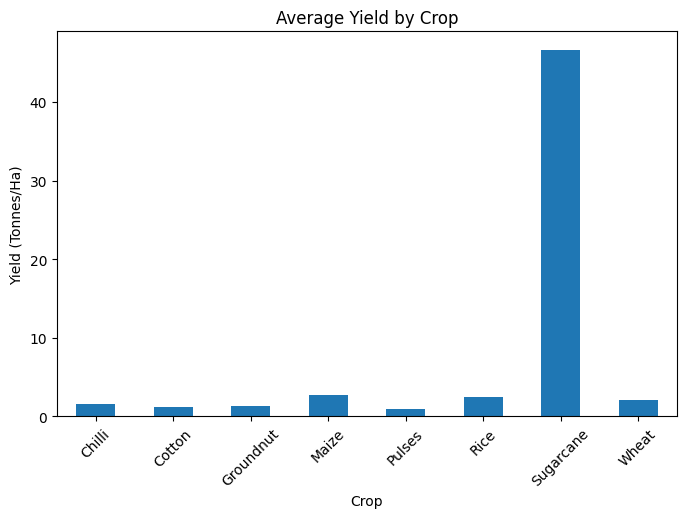

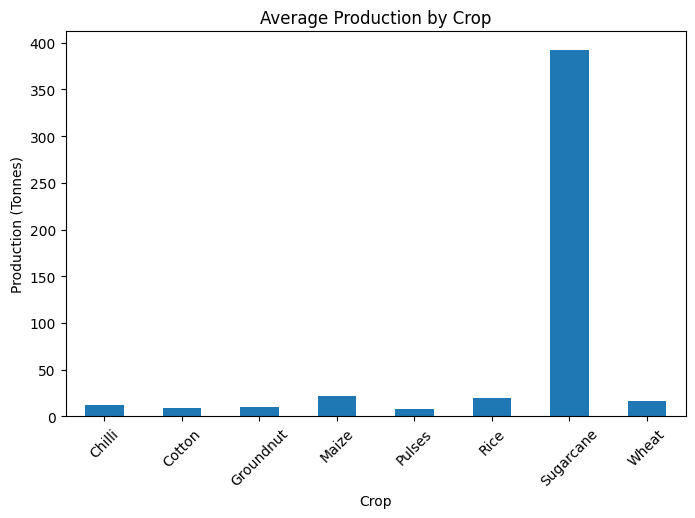

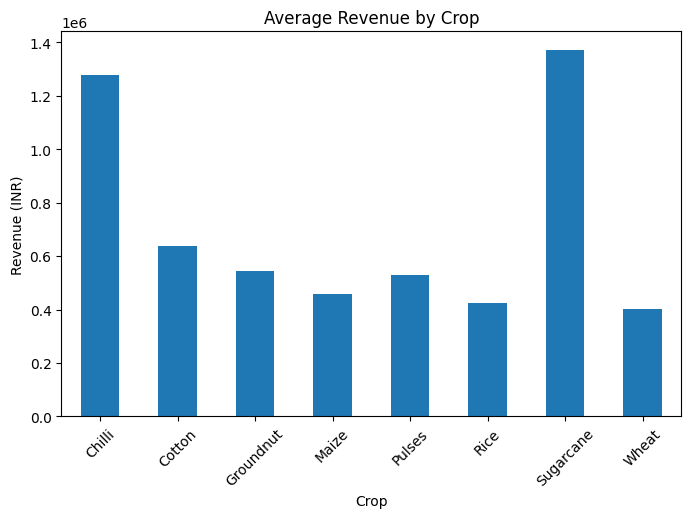

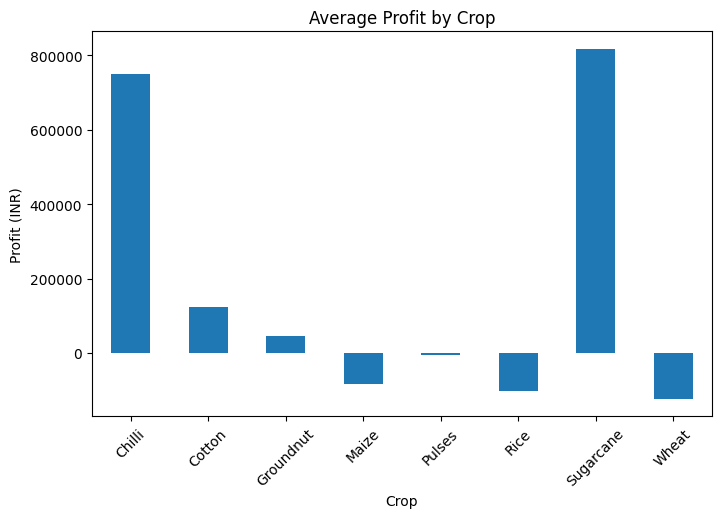

In [ ]:
import matplotlib.pyplot as plt

crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean()
crop_production = df.groupby('Crop')['Production_Tonnes'].mean()
crop_revenue = df.groupby('Crop')['Revenue_INR'].mean()
crop_profit = df.groupby('Crop')['Profit_INR'].mean()

crop_yield.plot(kind='bar', figsize=(8,5))
plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

crop_production.plot(kind='bar', figsize=(8,5))
plt.title('Average Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)
plt.show()

crop_revenue.plot(kind='bar', figsize=(8,5))
plt.title('Average Revenue by Crop')
plt.xlabel('Crop')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.show()

crop_profit.plot(kind='bar', figsize=(8,5))
plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45)
plt.show()

### Key Findings from Crop-wise Analysis

The crop-wise analysis shows significant differences in agricultural performance among the crops. Sugarcane has the highest average yield and production in the dataset and also shows the highest average profit. Chilli has relatively high average revenue and profit despite having a lower yield.

Pulses has the lowest average yield, while Rice, Maize, and Wheat show negative average profit in the dataset. The number of records also varies across crops, so the results should be interpreted based on the available observations.

These findings help compare crop-level productivity, revenue, and profitability.

In [ ]:
crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

crop_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Crop,,,,,,
Chilli,1.54,12.38,1276777.23,750878.34,4577.47,2.95
Cotton,1.23,9.40,639423.08,124546.92,5410.86,1.94
Groundnut,1.32,9.66,542935.50,44858.12,3459.54,3.15
Maize,2.71,21.78,457067.99,-83978.33,4377.78,5.60
Pulses,0.92,7.40,528465.87,-4238.05,2833.67,2.90
Rice,2.43,19.29,423615.26,-102213.50,10920.22,1.95
Sugarcane,46.64,392.41,1371980.11,817187.99,13897.70,30.48
Wheat,2.11,16.85,400104.89,-123398.34,4054.40,4.63


In [ ]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day,Yield_Tonnes_Ha
Season,,,,,,
Kharif,849.20,28.45,71.81,31.15,6.79,5.63
Rabi,437.62,23.49,57.89,24.07,7.59,5.04
Zaid,304.65,31.04,52.01,19.28,8.18,4.64


In [ ]:
environment_corr = df[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day',
    'Yield_Tonnes_Ha'
]].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').round(3)

environment_corr

,Yield_Tonnes_Ha
Rainfall_mm,0.031
Avg_Temperature_C,0.010
Humidity_pct,0.012
Soil_Moisture_pct,0.011
Sunlight_Hours_Day,-0.015


### Environmental Factors Analysis

The environmental conditions vary across the three agricultural seasons. Kharif has the highest average rainfall, humidity, and soil moisture. Zaid has the highest average temperature and sunlight hours but the lowest average rainfall and soil moisture.

The correlation analysis is used to examine the relationship between environmental factors and crop yield. Correlation values indicate the strength and direction of the relationship within the dataset, but they do not prove that one factor directly causes changes in yield.

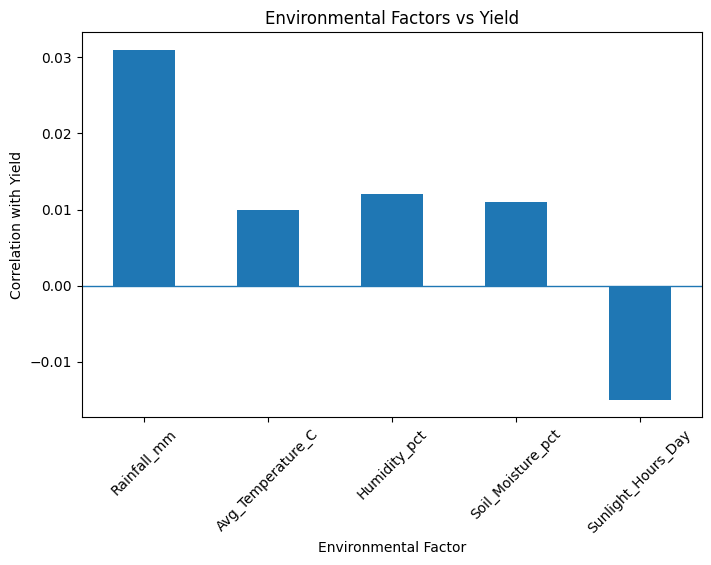

In [ ]:
environment_corr.plot(kind='bar', figsize=(8,5))

plt.title('Environmental Factors vs Yield')
plt.xlabel('Environmental Factor')
plt.ylabel('Correlation with Yield')
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

### Key Findings from Environmental Analysis

The correlation analysis shows that the environmental factors have very weak linear relationships with yield in this dataset. Rainfall has a small positive correlation with yield (0.031), while sunlight has a small negative correlation (-0.015). Temperature, humidity, and soil moisture also show correlations very close to zero.

Therefore, no strong linear relationship between the individual environmental factors and yield is observed in this dataset. Yield may depend on multiple factors together, such as crop type, farm conditions, inputs, irrigation, and other agricultural factors.

In [ ]:
resource_summary = df.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean'
}).round(2)

resource_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


In [ ]:
crop_resource_summary = df.groupby('Crop').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean'
}).round(2)

crop_resource_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Crop,,,,
Chilli,4577.47,2.95,188.73,5.13
Cotton,5410.86,1.94,185.42,5.11
Groundnut,3459.54,3.15,186.64,5.14
Maize,4377.78,5.60,191.32,5.11
Pulses,2833.67,2.90,183.34,4.99
Rice,10920.22,1.95,185.51,5.06
Sugarcane,13897.70,30.48,184.29,5.04
Wheat,4054.40,4.63,183.21,5.01


In [ ]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Flood,4.86,8026.47,3.44,73354.02
Rainfed,4.60,3549.55,7.56,79050.37
Sprinkler,5.16,6208.26,4.67,91121.08


In [ ]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


### Key Findings from Resource Usage and Efficiency Analysis

The resource analysis shows differences in water usage and efficiency across seasons and crops. Zaid has the highest average water usage and the lowest water efficiency among the three seasons. Kharif has the highest average water efficiency.

Among crops, Sugarcane has the highest average water usage but also has much higher water efficiency than the other crops. Rice has high water usage and relatively low water efficiency.

The irrigation analysis shows differences in yield, water usage, water efficiency, and profit. Drip irrigation has a high average yield and profit, while Rainfed farming has the highest average water efficiency. Flood irrigation has relatively high water usage and lower water efficiency.

These results describe patterns in this dataset and do not establish that one irrigation method directly causes higher yield or profit.

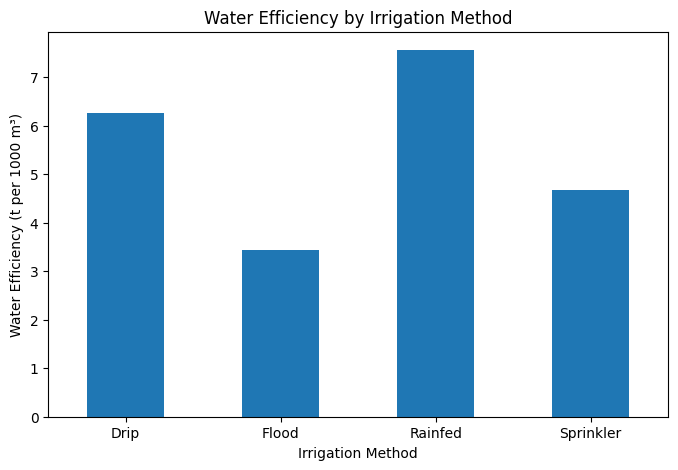

In [ ]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().plot(
    kind='bar', figsize=(8,5)
)

plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t per 1000 m³)')
plt.xticks(rotation=0)
plt.show()

In [ ]:
resource_final = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Profit_INR': 'mean'
}).round(2)

resource_final

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Profit_INR
Irrigation_Method,,,,,,
Drip,6.58,5918.75,6.27,186.28,5.16,219626.00
Flood,4.86,8026.47,3.44,185.76,5.10,73354.02
Rainfed,4.60,3549.55,7.56,186.88,4.98,79050.37
Sprinkler,5.16,6208.26,4.67,185.03,5.03,91121.08


In [ ]:
profit_summary = df.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

profit_summary

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


In [ ]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

profit_margin_summary = df.groupby('Season')['Profit_Margin_pct'].mean().round(2)

profit_margin_summary

,Profit_Margin_pct
Season,
Kharif,-38.64
Rabi,-44.27
Zaid,-69.35


In [ ]:
crop_profitability = df.groupby('Crop').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

crop_profitability

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Crop,,,,
Chilli,1276777.23,525898.89,750878.34,33.78
Cotton,639423.08,514876.17,124546.92,-8.23
Groundnut,542935.50,498077.38,44858.12,-28.66
Maize,457067.99,541046.32,-83978.33,-81.54
Pulses,528465.87,532703.92,-4238.05,-36.48
Rice,423615.26,525828.76,-102213.50,-99.37
Sugarcane,1371980.11,554792.13,817187.99,27.35
Wheat,400104.89,523503.22,-123398.34,-91.70


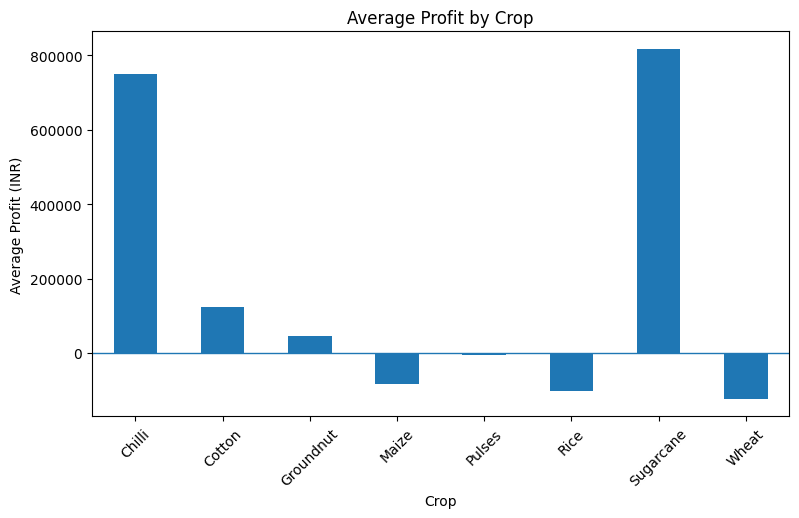

In [ ]:
crop_profitability['Profit_INR'].plot(kind='bar', figsize=(9,5))

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

### Key Findings from Profitability Analysis

The profitability analysis shows clear differences across seasons and crops. Kharif has the highest average revenue and profit, while Rabi has a lower positive average profit. Zaid has a negative average profit because its average cost is higher than its average revenue.

Among crops, Sugarcane and Chilli show high positive average profits. Cotton and Groundnut also show positive average profit. Maize, Pulses, Rice, and Wheat show negative average profit in the dataset.

The results indicate that revenue, production cost, crop type, and seasonal conditions are associated with differences in profitability. These findings are specific to the dataset and do not establish direct causation.

In [ ]:
profitability_final = df.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
}).round(2)

profitability_final

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,710719.06,531804.41,178914.65,-38.64
Rabi,601526.05,513836.58,87689.47,-44.27
Zaid,519171.90,543976.73,-24804.82,-69.35


In [ ]:
season_profitability = df.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
})

season_profitability['Profit_Margin_pct'] = (
    season_profitability['Profit_INR'] /
    season_profitability['Revenue_INR']
) * 100

season_profitability.round(2)

,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,710719.06,531804.41,178914.65,25.17
Rabi,601526.05,513836.58,87689.47,14.58
Zaid,519171.90,543976.73,-24804.82,-4.78


### Key Findings from Profitability Analysis

The profitability analysis shows differences in financial performance across the three seasons. Kharif has an average profit margin of 25.17%, followed by Rabi with 14.58%. Zaid has a negative average profit margin of -4.78%, indicating that its average cost is higher than its average revenue.

Kharif also has the highest average revenue and profit, while Zaid has the lowest average revenue and a negative average profit.

These results show that seasonal conditions are associated with differences in agricultural profitability within the dataset.

In [ ]:
overall_summary = {
    'Highest Yield Season': df.groupby('Season')['Yield_Tonnes_Ha'].mean().idxmax(),
    'Highest Profit Season': df.groupby('Season')['Profit_INR'].mean().idxmax(),
    'Highest Revenue Season': df.groupby('Season')['Revenue_INR'].mean().idxmax(),
    'Highest Water Efficiency Season': df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().idxmax(),
    'Highest Yield Crop': df.groupby('Crop')['Yield_Tonnes_Ha'].mean().idxmax(),
    'Highest Profit Crop': df.groupby('Crop')['Profit_INR'].mean().idxmax(),
    'Highest Water Efficiency Crop': df.groupby('Crop')['Water_Efficiency_t_per_1000m3'].mean().idxmax(),
    'Highest Profit Irrigation Method': df.groupby('Irrigation_Method')['Profit_INR'].mean().idxmax()
}

overall_summary

{'Highest Yield Season': 'Kharif',
 'Highest Profit Season': 'Kharif',
 'Highest Revenue Season': 'Kharif',
 'Highest Water Efficiency Season': 'Kharif',
 'Highest Yield Crop': 'Sugarcane',
 'Highest Profit Crop': 'Sugarcane',
 'Highest Water Efficiency Crop': 'Sugarcane',
 'Highest Profit Irrigation Method': 'Drip'}

### Overall Key Findings

The overall analysis of the Seasonal Agriculture Performance dataset shows clear differences in agricultural performance across seasons, crops, and irrigation methods.

1. Kharif has the highest average yield, revenue, profit, and water efficiency among the three seasons.
2. Zaid has the lowest average yield and profit and has a negative average profit margin.
3. Sugarcane has the highest average yield, production, profit, and water efficiency among the crops in the dataset.
4. Chilli also shows relatively high average revenue and profit.
5. Rice has high average water usage but relatively low water efficiency.
6. Drip irrigation has the highest average yield and profit among the irrigation methods.
7. Rainfed farming has the highest average water efficiency among the irrigation methods.
8. The environmental factors show very weak linear correlations with yield individually.
9. Resource usage and profitability vary considerably across crops and seasons.
10. The results are specific to the given dataset and should not be treated as general agricultural conclusions.



## Conclusion

The Seasonal Agriculture Performance Analysis project was conducted to understand how season, crop type, environmental conditions, resource usage, irrigation methods, and economic factors are related to agricultural performance.

The analysis shows that agricultural performance varies significantly across seasons and crops. Kharif shows the highest average yield, revenue, profit, and water efficiency, while Zaid shows lower overall performance and a negative average profit margin. Among crops, Sugarcane shows the highest average yield, production, profit, and water efficiency in the dataset. Drip irrigation shows higher average yield and profit compared with the other irrigation methods.

The environmental correlation analysis shows that the individual environmental factors have very weak linear relationships with yield in this dataset. This suggests that crop performance may depend on multiple factors together rather than on a single environmental factor.

Overall, the project provides a data-driven view of seasonal agricultural performance and helps identify patterns in productivity, resource efficiency, and profitability.

## Limitations

1. The analysis is based only on the available dataset and may not represent all agricultural regions or farms.
2. The number of observations varies across seasons and crops.
3. Correlation analysis does not establish cause-and-effect relationships.
4. Some variables contain outliers that were retained because they may represent genuine farm-level variation.
5. The analysis mainly uses averages and simple statistical relationships; more advanced predictive models were not included.

# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 2026–2027

**Major Project**

This project analyzes agricultural performance across different seasons, crops, environmental conditions, resource usage, irrigation methods, and economic factors using data analysis techniques.

## Project Objectives

- Analyze agricultural performance across different seasons.
- Compare crop-wise yield, production, revenue, and profit.
- Study the relationship between environmental factors and yield.
- Analyze water usage and water efficiency.
- Compare different irrigation methods.
- Evaluate agricultural profitability.
- Identify important patterns and insights from the dataset.

## Methodology

The project was completed using the following steps:

1. Dataset loading and inspection
2. Data cleaning and preprocessing
3. Missing value handling
4. Duplicate and data type checking
5. Outlier identification
6. Seasonal analysis
7. Crop-wise analysis
8. Environmental factor analysis
9. Resource usage and efficiency analysis
10. Profitability analysis
11. Data visualization
12. Overall findings and conclusion

## Tools and Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- CSV Dataset

In [ ]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (4000, 29)
Missing Values: 0
Duplicate Rows: 0


In [ ]:
df.to_csv('seasonal_agriculture_performance_cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
from google.colab import files

files.download('seasonal_agriculture_performance_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>